In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/datasets/satyamsatyarthi2006/titanic-survival/Titanic-Dataset.xls')
print("Shape:", df.shape)
print(df.head())
print(df.dtypes)

Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

Null values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


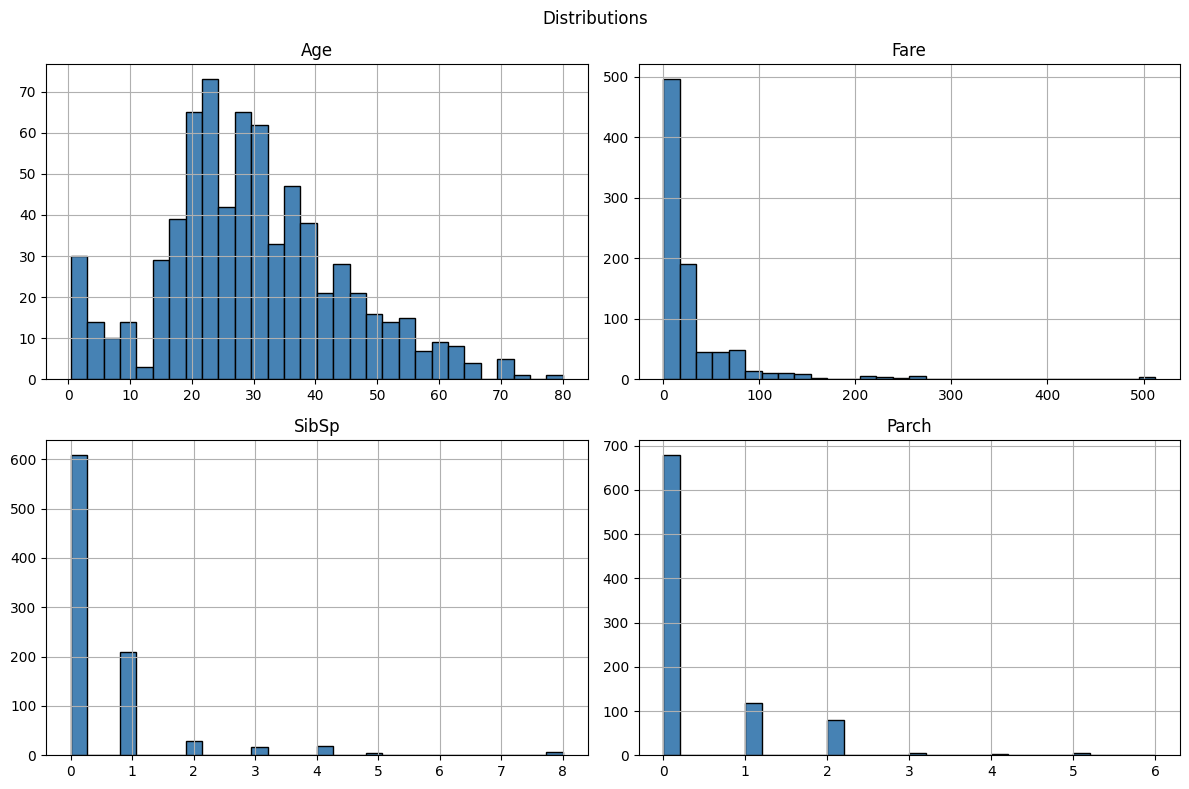

Nulls after cleaning:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Shape: (891, 8)
Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2


In [2]:
print("Null values:\n", df.isnull().sum())

num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df[num_cols].hist(bins=30, figsize=(12, 8), color='steelblue', edgecolor='black')
plt.suptitle('Distributions')
plt.tight_layout()
plt.show()
df['Age'].fillna(df['Age'].median(), inplace=True)
df.drop(columns=['Cabin'], inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

print("Nulls after cleaning:\n", df.isnull().sum())
print("Shape:", df.shape)
le = LabelEncoder()
df['Sex']      = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

for col in ['Sex', 'Embarked', 'Pclass', 'SibSp', 'Parch']:
    df[col] = df[col].astype(int)

print(df.dtypes)
print(df.head())

In [3]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Age_bin']    = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                          labels=[0,1,2,3,4]).astype(int)
df.drop(columns=['SibSp', 'Parch', 'Age'], inplace=True)

print("Shape:", df.shape)
print(df.head())
X = df.drop('Survived', axis=1)
y = df['Survived']

# no StandardScaler — only MinMax for chi² selection
X_mm = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)
selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_mm, y)

feat_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score'  : selector.scores_,
    'P-value': selector.pvalues_
}).sort_values('Score', ascending=False)

print(feat_scores.to_string(index=False))

drop_cols = feat_scores[feat_scores['P-value'] > 0.05]['Feature'].tolist()
print(f"\nDropping: {drop_cols}")

X_final = X.drop(columns=drop_cols)  # raw unscaled X
y_final = y.reset_index(drop=True)
print("Final features:", X_final.columns.tolist())

Shape: (891, 8)
   Survived  Pclass  Sex     Fare  Embarked  FamilySize  IsAlone  Age_bin
0         0       3    1   7.2500         2           2        0        2
1         1       1    0  71.2833         0           2        0        3
2         1       3    0   7.9250         2           1        1        2
3         1       1    0  53.1000         2           2        0        2
4         0       3    1   8.0500         2           1        1        2
   Feature     Score      P-value
       Sex 92.702447 6.077838e-22
    Pclass 27.232933 1.803602e-07
   IsAlone 14.640793 1.300685e-04
      Fare  8.819172 2.980820e-03
  Embarked  5.101262 2.390844e-02
   Age_bin  0.669997 4.130528e-01
FamilySize  0.070909 7.900177e-01

Dropping: ['Age_bin', 'FamilySize']
Final features: ['Pclass', 'Sex', 'Fare', 'Embarked', 'IsAlone']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (712, 5)
Test size : (179, 5)


Parent Entropy: 0.9555

  Pclass       → IG: 0.0000
  Sex          → IG: 0.0000
  Fare         → IG: 0.0457
  Embarked     → IG: 0.0000
  IsAlone      → IG: 0.0000

Best Root Node: 'Fare'


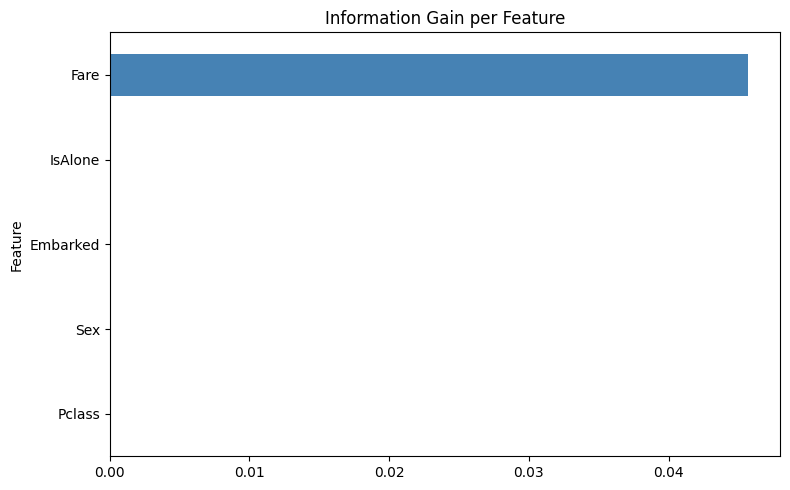

In [5]:
def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-10))

def information_gain(X_col, y):
    parent_entropy = entropy(y)
    threshold = X_col.median()
    left  = y[X_col <= threshold]
    right = y[X_col >  threshold]
    n = len(y)
    child_entropy = (len(left)/n) * entropy(left) + (len(right)/n) * entropy(right)
    return parent_entropy - child_entropy

parent_e = entropy(y_train)
print(f"Parent Entropy: {parent_e:.4f}\n")

ig_scores = {}
for col in X_train.columns:
    ig = information_gain(X_train[col], y_train)
    ig_scores[col] = ig
    print(f"  {col:12} → IG: {ig:.4f}")

best_root = max(ig_scores, key=ig_scores.get)
print(f"\nBest Root Node: '{best_root}'")

# plot
ig_df = pd.DataFrame({'Feature': ig_scores.keys(),
                      'Info Gain': ig_scores.values()}).sort_values('Info Gain', ascending=True)
ig_df.plot(kind='barh', x='Feature', y='Info Gain',
           color='steelblue', figsize=(8,5), legend=False)
plt.title('Information Gain per Feature')
plt.tight_layout()
plt.show()

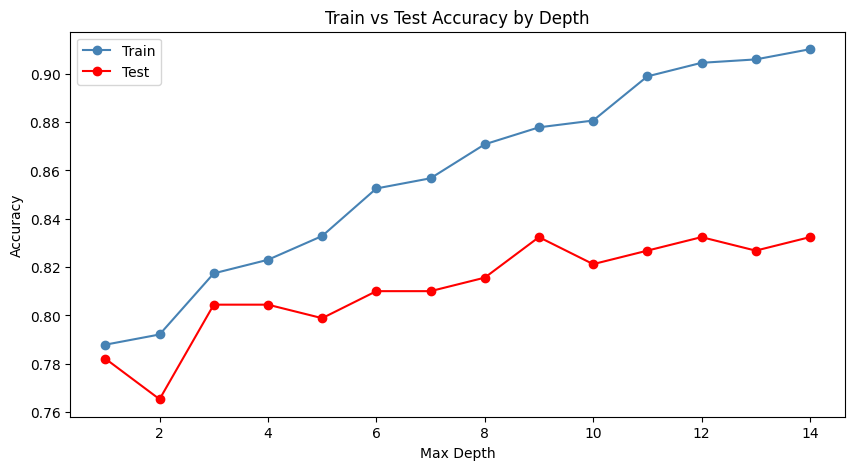

Best depth: 9 → Accuracy: 0.8324


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

train_scores, test_scores = [], []

for depth in range(1, 15):
    dt_d = DecisionTreeClassifier(criterion='entropy',
                                   max_depth=depth, random_state=42)
    dt_d.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt_d.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  dt_d.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 15), train_scores, marker='o', label='Train', color='steelblue')
plt.plot(range(1, 15), test_scores,  marker='o', label='Test',  color='red')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy by Depth')
plt.legend()
plt.show()

best_depth = test_scores.index(max(test_scores)) + 1
print(f"Best depth: {best_depth} → Accuracy: {max(test_scores):.4f}")

Accuracy  : 0.8268
Precision : 0.8644
Recall    : 0.6892
F1 Score  : 0.7669


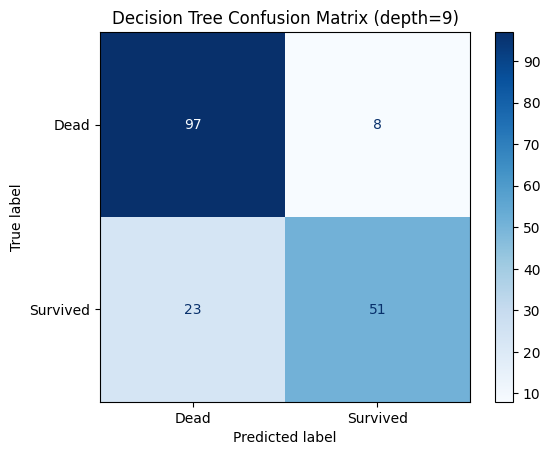

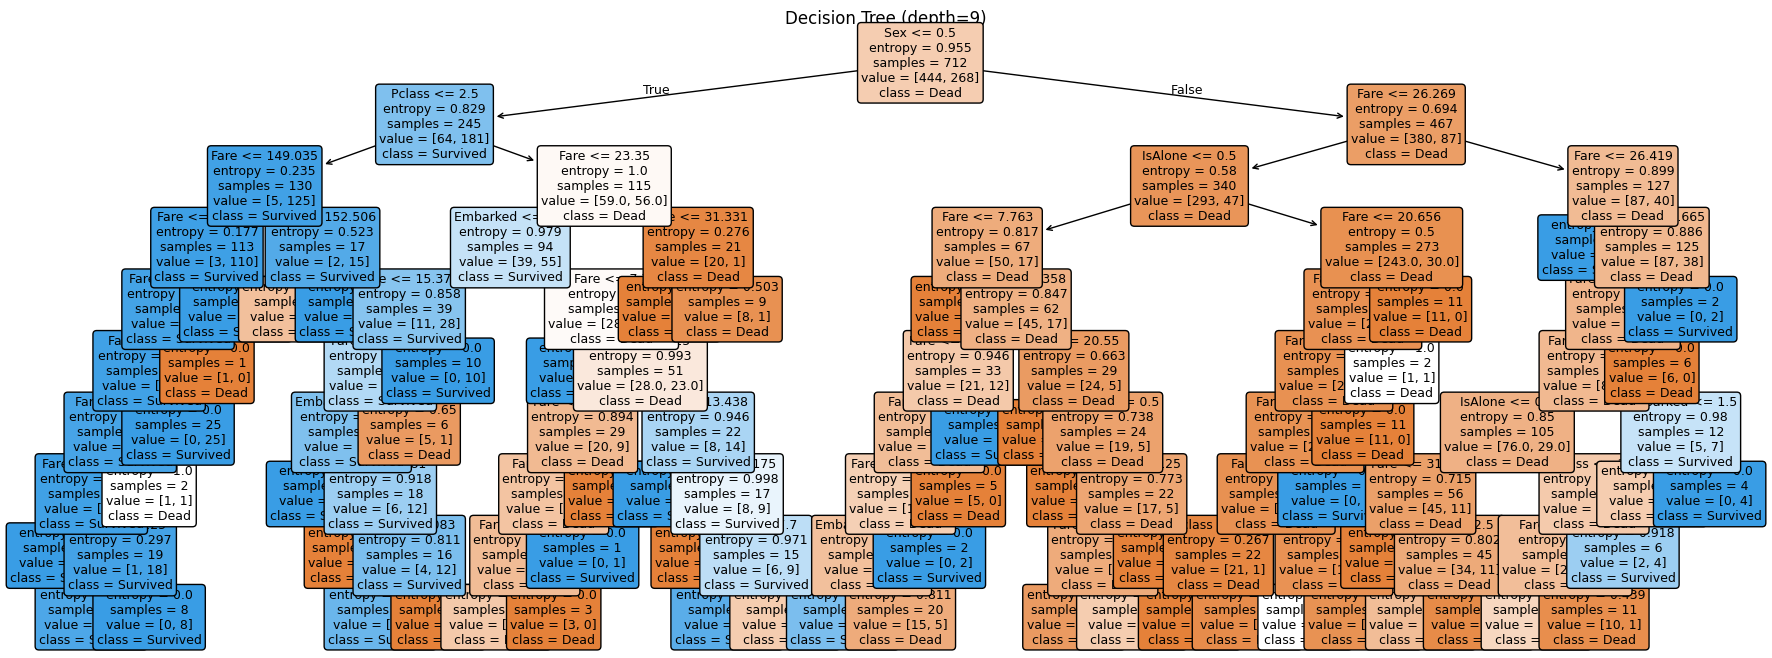


CV Accuracy: 0.8103 ± 0.0235
Each fold  : [0.7933 0.7865 0.8539 0.809  0.809 ]


In [7]:
from sklearn.tree import plot_tree
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)
from sklearn.model_selection import cross_val_score

dt = DecisionTreeClassifier(criterion='entropy',
                             max_depth=best_depth,
                             min_samples_split=10,
                             random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Dead', 'Survived']).plot(cmap='Blues')
plt.title(f'Decision Tree Confusion Matrix (depth={best_depth})')
plt.show()

# tree visualization
plt.figure(figsize=(22, 8))
plot_tree(dt,
          feature_names=X_train.columns.tolist(),
          class_names=['Dead', 'Survived'],
          filled=True, rounded=True, fontsize=9)
plt.title(f'Decision Tree (depth={best_depth})')
plt.show()

# cross validation
scores = cross_val_score(dt, X_final, y_final, cv=5, scoring='accuracy')
print(f"\nCV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Each fold  : {scores.round(4)}")